<a href="https://colab.research.google.com/github/almasmadii/Google-Collab-Analysis-project/blob/main/Space_Missions_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [45]:
%pip install iso3166

### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [46]:
%pip install --upgrade plotly

### Import Statements

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [ ]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`?
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [ ]:
df_data.shape

(4324, 9)

In [ ]:
df_data.size
df_data.duplicated().sum()


np.int64(0)

## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data.

In [ ]:
df_data=df_data.dropna()

In [ ]:
df_data.head()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success
5,5,5,CASC,"LC-9, Taiyuan Satellite Launch Center, China","Sat Jul 25, 2020 03:13 UTC","Long March 4B | Ziyuan-3 03, Apocalypse-10 & N...",StatusActive,64.68,Success


## Descriptive Statistics

In [ ]:
df_data.describe()

,Unnamed: 0.1,Unnamed: 0
count,964.00,964.00
mean,858.49,858.49
std,784.21,784.21
min,0.00,0.00
25%,324.75,324.75
50%,660.50,660.50
75%,"1,112.00","1,112.00"
max,"4,020.00","4,020.00"


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

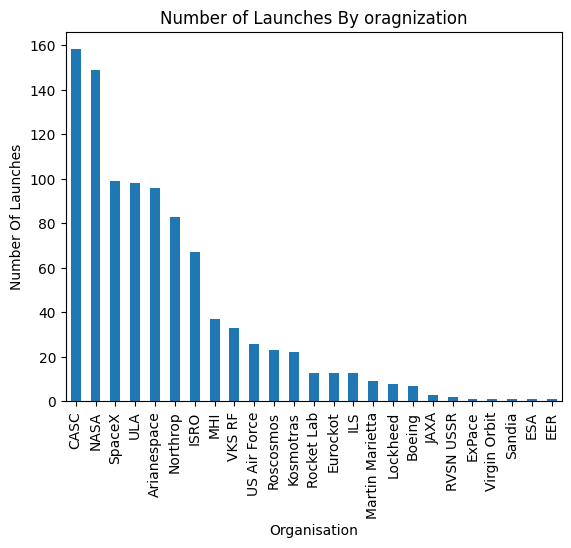

In [ ]:
launch_counts = df_data["Organisation"].value_counts()
plt.figure()
launch_counts.plot(kind='bar')
plt.title("Number of Launches By oragnization")
plt.xlabel("Organisation")
plt.ylabel("Number Of Launches")
plt.show()

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned?

In [ ]:
rocket_status_counts=df_data["Rocket_Status"].value_counts()

In [ ]:
print(rocket_status_counts)

Rocket_Status
StatusActive     586
StatusRetired    378
Name: count, dtype: int64


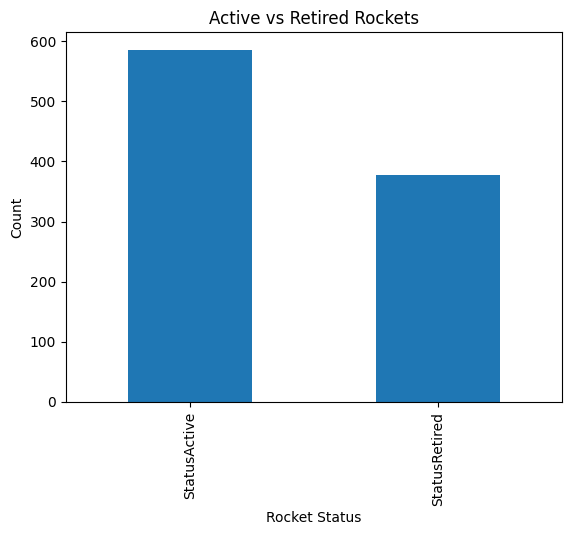

In [ ]:
plt.figure()
rocket_status_counts.plot(kind='bar')

plt.title("Active vs Retired Rockets")
plt.xlabel("Rocket Status")
plt.ylabel("Count")

plt.show()

# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [ ]:
mission_status_counts = df_data["Mission_Status"].value_counts()
print(mission_status_counts)

Mission_Status
Success              910
Failure               36
Partial Failure       17
Prelaunch Failure      1
Name: count, dtype: int64


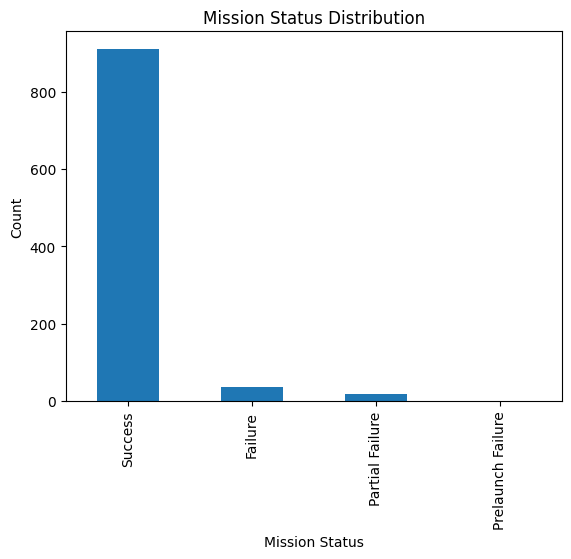

In [ ]:
plt.figure()
mission_status_counts.plot(kind='bar')

plt.title("Mission Status Distribution")
plt.xlabel("Mission Status")
plt.ylabel("Count")

plt.show()

# How Expensive are the Launches?

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values).

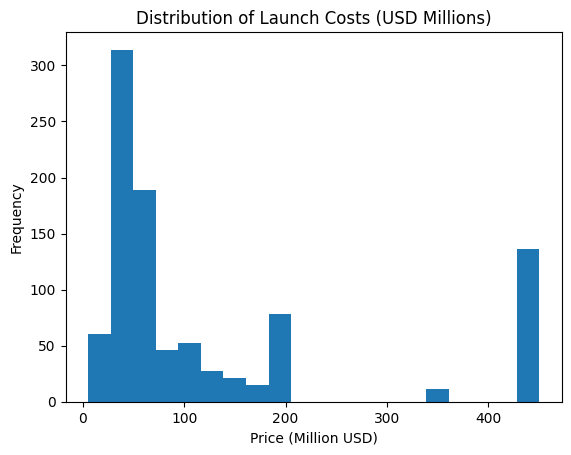

In [ ]:
price = df_data["Price"].dropna()
price = pd.to_numeric(price, errors='coerce')
price = price.dropna()
plt.figure()
plt.hist(price, bins=20)

plt.title("Distribution of Launch Costs (USD Millions)")
plt.xlabel("Price (Million USD)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
df_data.head()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success
5,5,5,CASC,"LC-9, Taiyuan Satellite Launch Center, China","Sat Jul 25, 2020 03:13 UTC","Long March 4B | Ziyuan-3 03, Apocalypse-10 & N...",StatusActive,64.68,Success


# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map.
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [ ]:
df_data["Country"] = df_data["Location"].apply(lambda x: x.split(",")[-1].strip())

In [ ]:
df_data["Country"] = df_data["Country"].replace({
    "Russia": "Russian Federation",
    "New Mexico": "USA",
    "Yellow Sea": "China",
    "Shahrud Missile Test Site": "Iran",
    "Pacific Missile Range Facility": "USA",
    "Barents Sea": "Russian Federation",
    "Gran Canaria": "USA"
})

In [ ]:
from iso3166 import countries

def get_alpha3(country_name):
    try:
        return countries.get(country_name).alpha3
    except:
        return None

df_data["ISO_Code"] = df_data["Country"].apply(get_alpha3)
country_counts = df_data.groupby("ISO_Code").size().reset_index(name="Launch_Count")
fig = px.choropleth(
    country_counts,
    locations="ISO_Code",
    color="Launch_Count",
    color_continuous_scale="matter",  # nice color scale
    title="Number of Launches by Country"
)

fig.show()

# Use a Choropleth Map to Show the Number of Failures by Country


In [ ]:
failures = df_data[df_data["Mission_Status"] != "Success"]

In [ ]:
def get_alpha3(name):
    try:
        return countries.get(name).alpha3
    except:
        return None

failures["ISO"] = failures["Country"].apply(get_alpha3)

/tmp/ipykernel_10444/4286043326.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  failures["ISO"] = failures["Country"].apply(get_alpha3)


In [ ]:
failure_counts = failures.groupby("ISO").size().reset_index(name="Failures")

In [ ]:
fig = px.choropleth(
    failure_counts,
    locations="ISO",
    color="Failures",
    color_continuous_scale="matter",
    title="Mission Failures by Country"
)

fig.show()

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status.

In [ ]:
fig = px.sunburst(
    df_data,
    path=["Country", "Organisation", "Mission_Status"],
    title="Sunburst: Country → Organisation → Mission Status"
)

fig.show()

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [ ]:
df_data["Price"] = pd.to_numeric(df_data["Price"], errors="coerce")

In [ ]:
total_spending = df_data.groupby("Organisation")["Price"].sum().sort_values(ascending=False)

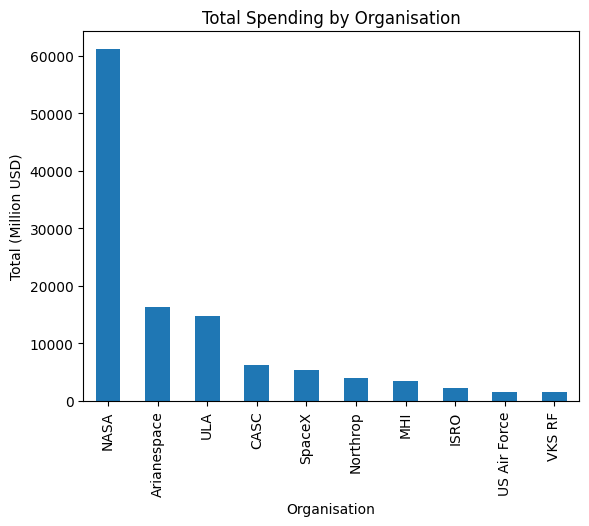

In [ ]:
total_spending.head(10).plot(kind="bar")

plt.title("Total Spending by Organisation")
plt.ylabel("Total (Million USD)")
plt.show()

# Analyse the Amount of Money Spent by Organisation per Launch

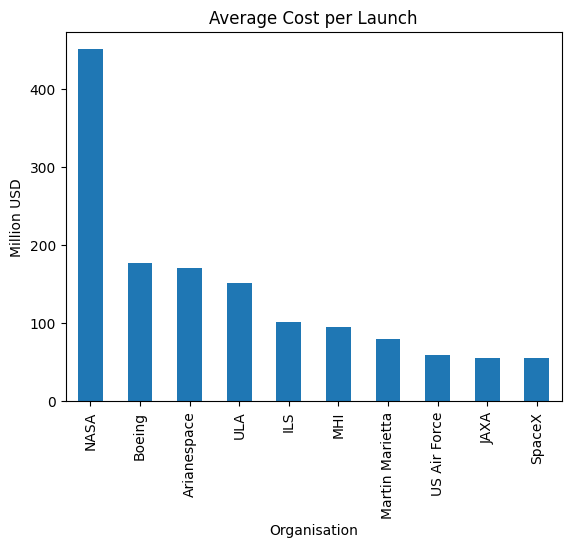

In [ ]:
avg_spending = df_data.groupby("Organisation")["Price"].mean().sort_values(ascending=False)

avg_spending.head(10).plot(kind="bar")

plt.title("Average Cost per Launch")
plt.ylabel("Million USD")
plt.show()

# Chart the Number of Launches per Year

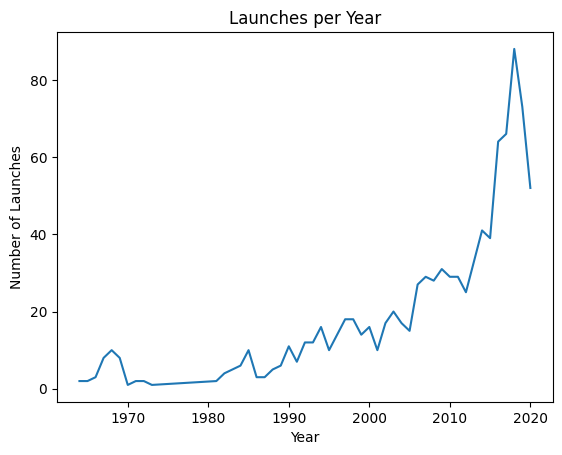

In [ ]:
df_data["Date"] = pd.to_datetime(df_data["Date"],format='mixed',utc=True)

launches_per_year = df_data["Date"].dt.year.value_counts().sort_index()

launches_per_year.plot()

plt.title("Launches per Year")
plt.xlabel("Year")
plt.ylabel("Number of Launches")
plt.show()


In [ ]:
df_data["Date"] = pd.to_datetime(df_data["Date"], errors="coerce")

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart.

/tmp/ipykernel_10444/2601758890.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df_data.set_index("Date").resample("M").size()


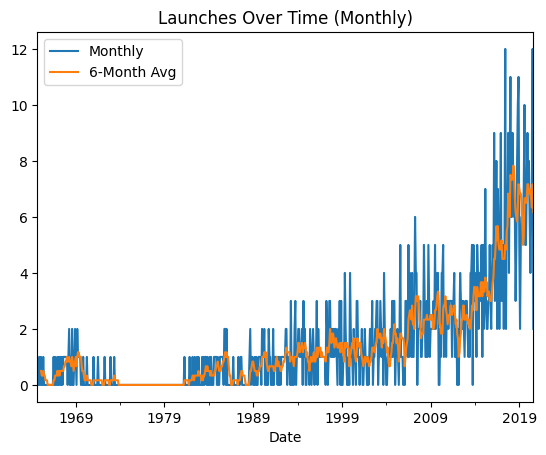

In [ ]:

monthly = df_data.set_index("Date").resample("M").size()

rolling = monthly.rolling(window=6).mean()

plt.figure()
monthly.plot(label="Monthly")
rolling.plot(label="6-Month Avg")

plt.legend()
plt.title("Launches Over Time (Monthly)")
plt.show()

# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

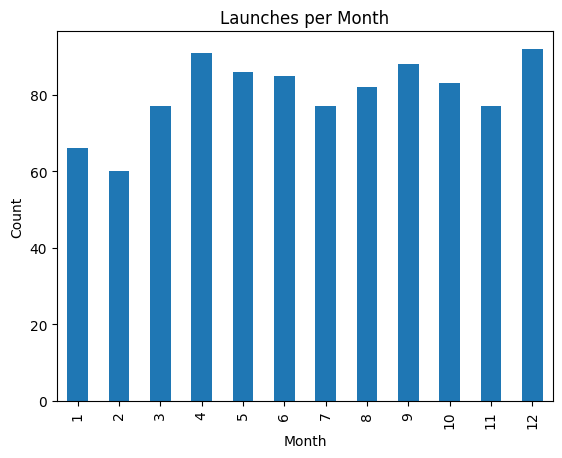

In [ ]:
df_data["Month"] = df_data["Date"].dt.month

month_counts = df_data["Month"].value_counts().sort_index()

month_counts.plot(kind="bar")

plt.title("Launches per Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

# How has the Launch Price varied Over Time?

Create a line chart that shows the average price of rocket launches over time.

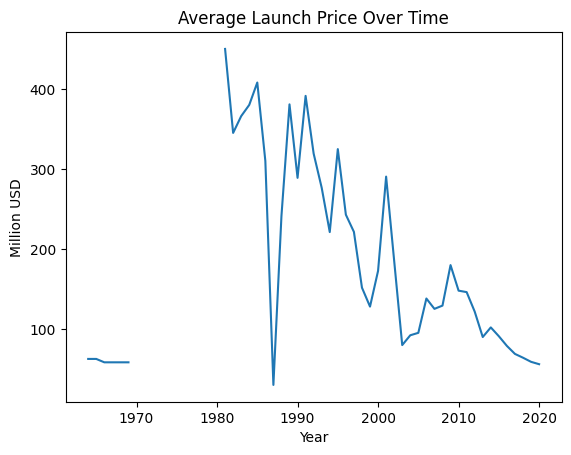

In [ ]:
price_trend = df_data.groupby(df_data["Date"].dt.year)["Price"].mean()

price_trend.plot()

plt.title("Average Launch Price Over Time")
plt.xlabel("Year")
plt.ylabel("Million USD")
plt.show()

# Chart the Number of Launches over Time by the Top 10 Organisations.

How has the dominance of launches changed over time between the different players?

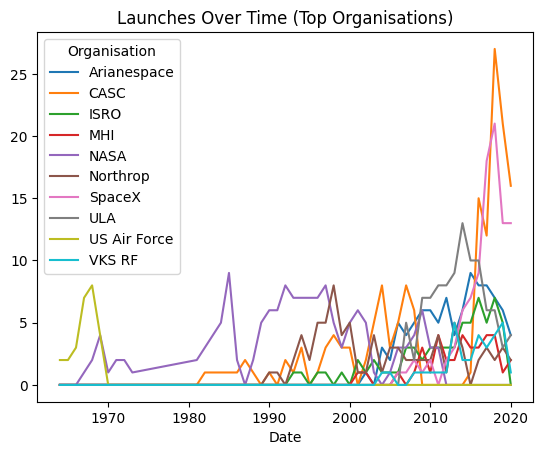

In [ ]:
top_orgs = df_data["Organisation"].value_counts().head(10).index

filtered = df_data[df_data["Organisation"].isin(top_orgs)]

pivot = filtered.pivot_table(
    index=df_data["Date"].dt.year,
    columns="Organisation",
    aggfunc="size",
    fill_value=0
)

pivot.plot()

plt.title("Launches Over Time (Top Organisations)")
plt.show()
